# Compare Predictions from Two Models

This notebook compares two submission-style classification outputs with columns `row_id` and `class_id`.

It reports:
- basic validation checks
- agreement/disagreement counts
- per-class distribution differences
- disagreement matrix (Model A vs Model B)
- optional CSV export of mismatched rows

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

sns.set_theme(style='whitegrid')

In [35]:
# Update these paths if needed
MODEL_A_PATH = Path('/workspace/github/pig_posture_kaggle_project/data/generated/train2_local_run/single_strategy/submission_single.csv')
MODEL_B_PATH = Path('/workspace/github/pig_posture_kaggle_project/data/generated/train2_local_run/single_strategy/submission_single_train2_imgaug_f1selection.csv')

MODEL_A_NAME = 'single'
MODEL_B_NAME = 'single_imgaug_f1'

MODEL_A_PATH, MODEL_B_PATH

(PosixPath('/workspace/github/pig_posture_kaggle_project/data/generated/train2_local_run/single_strategy/submission_single.csv'),
 PosixPath('/workspace/github/pig_posture_kaggle_project/data/generated/train2_local_run/single_strategy/submission_single_train2_imgaug_f1selection.csv'))

In [37]:
def _validate_submission(df: pd.DataFrame, name: str) -> None:
    required = {'row_id', 'class_id'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'{name} missing required columns: {missing}')

    if df['row_id'].duplicated().any():
        n_dup = int(df['row_id'].duplicated().sum())
        raise ValueError(f'{name} has {n_dup} duplicated row_id values')

    if df['class_id'].isna().any():
        raise ValueError(f'{name} has NaN class_id values')

    # Keep class_id as int for safe comparisons
    df['class_id'] = df['class_id'].astype(int)


a = pd.read_csv(MODEL_A_PATH)
b = pd.read_csv(MODEL_B_PATH)

_validate_submission(a, MODEL_A_NAME)
_validate_submission(b, MODEL_B_NAME)

print(f'{MODEL_A_NAME}: {len(a):,} rows')
print(f'{MODEL_B_NAME}: {len(b):,} rows')

single: 11,708 rows
single_imgaug_f1: 11,708 rows


In [38]:
cmp_df = (
    a[['row_id', 'class_id']]
    .rename(columns={'class_id': 'class_a'})
    .merge(
        b[['row_id', 'class_id']].rename(columns={'class_id': 'class_b'}),
        on='row_id',
        how='inner'
    )
)

a_only = a[~a['row_id'].isin(cmp_df['row_id'])]
b_only = b[~b['row_id'].isin(cmp_df['row_id'])]

cmp_df['agree'] = cmp_df['class_a'] == cmp_df['class_b']

print(f'Common row_id: {len(cmp_df):,}')
print(f'Only in {MODEL_A_NAME}: {len(a_only):,}')
print(f'Only in {MODEL_B_NAME}: {len(b_only):,}')

agree_count = int(cmp_df['agree'].sum())
disagree_count = int((~cmp_df['agree']).sum())
agree_rate = agree_count / len(cmp_df) if len(cmp_df) else np.nan

print(f'Agreement: {agree_count:,} / {len(cmp_df):,} ({agree_rate:.2%})')
print(f'Disagreement: {disagree_count:,}')

Common row_id: 11,708
Only in single: 0
Only in single_imgaug_f1: 0
Agreement: 8,780 / 11,708 (74.99%)
Disagreement: 2,928


In [39]:
# Agreement summary
summary = pd.DataFrame({
    'metric': ['common_rows', 'agree_count', 'disagree_count', 'agree_rate'],
    'value': [len(cmp_df), agree_count, disagree_count, agree_rate],
})
summary

,metric,value
0,common_rows,11708.000000
1,agree_count,8780.000000
2,disagree_count,2928.000000
3,agree_rate,0.749915


In [40]:
# Disagreement matrix: rows = Model A class, cols = Model B class
cm = pd.crosstab(cmp_df['class_a'], cmp_df['class_b'])
cm

class_b,0,1,2,3,4
class_a,,,,,
0,339,44,12,61,105
1,128,458,12,109,117
2,18,17,141,152,91
3,109,158,215,5899,727
4,105,141,123,484,1943


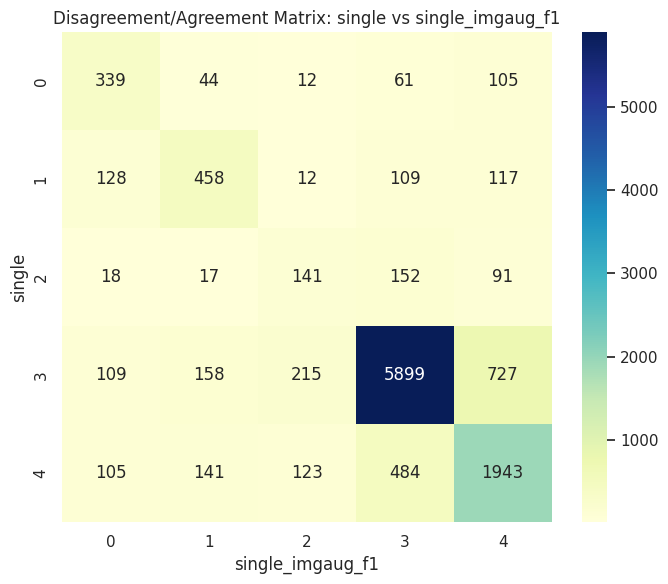

In [41]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Disagreement/Agreement Matrix: {MODEL_A_NAME} vs {MODEL_B_NAME}')
plt.xlabel(MODEL_B_NAME)
plt.ylabel(MODEL_A_NAME)
plt.tight_layout()
plt.show()

In [42]:
# Class distribution comparison
dist_a = cmp_df['class_a'].value_counts(normalize=True).sort_index()
dist_b = cmp_df['class_b'].value_counts(normalize=True).sort_index()
all_classes = sorted(set(dist_a.index).union(dist_b.index))
dist_df = pd.DataFrame({
    MODEL_A_NAME: [dist_a.get(c, 0.0) for c in all_classes],
    MODEL_B_NAME: [dist_b.get(c, 0.0) for c in all_classes],
}, index=all_classes)
dist_df['delta'] = dist_df[MODEL_A_NAME] - dist_df[MODEL_B_NAME]
dist_df.index.name = 'class_id'
dist_df

,single,single_imgaug_f1,delta
class_id,,,
0,0.047916,0.059703,-0.011787
1,0.070379,0.069867,0.000512
2,0.035787,0.042962,-0.007175
3,0.607106,0.572685,0.034421
4,0.238811,0.254783,-0.015972


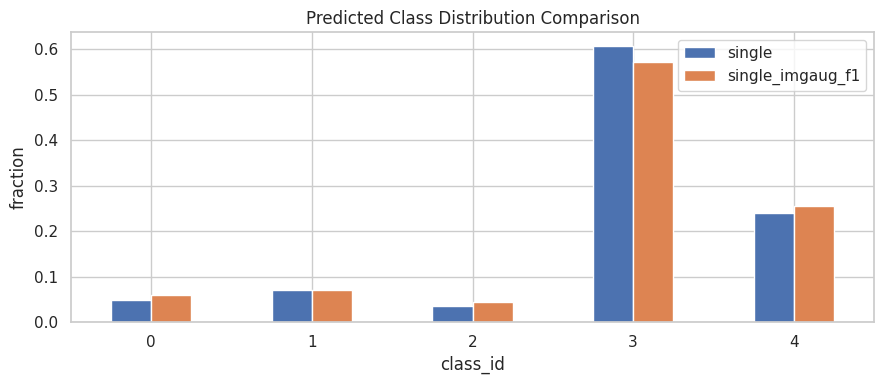

In [43]:
ax = dist_df[[MODEL_A_NAME, MODEL_B_NAME]].plot(kind='bar', figsize=(9, 4))
ax.set_title('Predicted Class Distribution Comparison')
ax.set_xlabel('class_id')
ax.set_ylabel('fraction')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
# Top disagreement transitions
transitions = (
    cmp_df.loc[~cmp_df['agree'], ['class_a', 'class_b']]
    .value_counts()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
)
transitions.head(20)

,class_a,class_b,count
0,3,4,727
1,4,3,484
2,3,2,215
3,3,1,158
4,2,3,152
5,4,1,141
6,1,0,128
7,4,2,123
8,1,4,117
9,1,3,109


In [45]:
# Save mismatched rows for manual review
out_path = Path('/workspace/github/pig_posture_kaggle_project/data/generated/train2_local_run/model_comparison_disagreements.csv')
mismatches = cmp_df.loc[~cmp_df['agree']].copy()
mismatches.to_csv(out_path, index=False)
print(f'Saved {len(mismatches):,} mismatches to: {out_path}')

Saved 2,928 mismatches to: /workspace/github/pig_posture_kaggle_project/data/generated/train2_local_run/model_comparison_disagreements.csv


mismatches1 = mismatches.copy()

In [46]:
mismatches1.shape, mismatches.shape

((3276, 4), (2928, 4))

In [51]:
common_row_ids = set(mismatches1['row_id']).intersection(mismatches['row_id'])
print("# Common row_ids:", len(common_row_ids))

# Common row_ids: 1694
